In [1]:
# ─── Cell 1: تحقق من البيئة ───────────────────────────────────────────
!nvidia-smi
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

# ⚠️ مهم جداً: لا تحاول تغيير إصدار torch هنا أبداً
# Colab 2025 يأتي بـ torch 2.10+cu128 وهو متوافق مع CUDA 12.8

Sat Apr  4 20:14:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ─── Cell 2: تثبيت المكتبات (بدون تغيير torch) ──────────────────────
!pip install -q \
    transformers>=4.48.0 \
    opencv-python-headless \
    Pillow \
    numpy \
    matplotlib \
    rasterio \
    kagglehub \
    supervision \
    timm

print('✅ المكتبات جاهزة')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 133.1 MB/s eta 0:00:00
✅ المكتبات جاهزة


In [3]:
# ─── Cell 3: تثبيت GroundingDINO + Patch لإصلاح _C ──────────────────
import os, sys

# احذف أي نسخة قديمة
if os.path.exists('/content/GroundingDINO'):
    !rm -rf /content/GroundingDINO

!git clone -q https://github.com/IDEA-Research/GroundingDINO.git /content/GroundingDINO

# ================================================================
# 🔧 PATCH: نستبدل CUDA extension بـ Python fallback
#    السبب: _C لا يمكن بناؤها لأن CUDA system (12.8) لا يتوافق مع
#    أي إصدار قديم من torch، والإصدار الجديد (2.10) فيه deprecated API.
#    الحل: نجبر GroundingDINO تستخدم Python implementation دائماً.
# ================================================================
patch_file = '/content/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py'

with open(patch_file, 'r') as f:
    code = f.read()

# البحث عن السطر if value.is_cuda: وتغييره إلى if False:
# هذا يجبر المكتبة تستخدم ms_deform_attn_core_pytorch دائماً
patched = code.replace(
    'if value.is_cuda:',
    'if False:  # PATCHED: force Python fallback, no _C CUDA extension needed'
)

if 'PATCHED' in patched:
    with open(patch_file, 'w') as f:
        f.write(patched)
    print('✅ Patch نُفِّذ بنجاح — GroundingDINO سيشتغل بـ Python fallback')
else:
    print('⚠️  نص الـ patch لم يُطبَّق — المكتبة قد تكون تغيرت. سنكمل على كل حال.')

# تثبيت بدون بناء C extension
!pip install -q -e /content/GroundingDINO --no-build-isolation 2>&1 | tail -3

# إضافة للـ path
sys.path.insert(0, '/content/GroundingDINO')

# تحقق من الاستيراد
from groundingdino.util.inference import load_model, load_image, predict
print('✅ GroundingDINO جاهز')

⚠️  نص الـ patch لم يُطبَّق — المكتبة قد تكون تغيرت. سنكمل على كل حال.
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
✅ GroundingDINO جاهز


In [4]:
# ─── Cell 4: تثبيت SAM ───────────────────────────────────────────────
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

from segment_anything import sam_model_registry, SamPredictor
print('✅ SAM جاهز')

  Preparing metadata (setup.py) ... done
✅ SAM جاهز


In [5]:
# ─── Cell 5: تحميل الأوزان ───────────────────────────────────────────
import os

os.makedirs('/content/weights', exist_ok=True)

# Grounding DINO weights
gdino_path = '/content/weights/gdino.pth'
if not os.path.exists(gdino_path):
    print('⬇️  تحميل Grounding DINO weights...')
    !wget -q --show-progress \
        https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth \
        -O {gdino_path}
else:
    print('✅ DINO weights موجودة مسبقاً')

# SAM weights (ViT-H)
sam_path = '/content/weights/sam_vit_h_4b8939.pth'
if not os.path.exists(sam_path):
    print('⬇️  تحميل SAM weights (2.5GB)...')
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \
        -O {sam_path}
else:
    print('✅ SAM weights موجودة مسبقاً')

print(f'DINO: {os.path.getsize(gdino_path)/1e6:.0f} MB')
print(f'SAM:  {os.path.getsize(sam_path)/1e6:.0f} MB')
print('✅ الأوزان جاهزة')

⬇️  تحميل Grounding DINO weights...
/content/weights/gd 100%[===================>] 661.85M   218MB/s    in 3.0s    
⬇️  تحميل SAM weights (2.5GB)...
/content/weights/sa 100%[===================>]   2.39G   157MB/s    in 19s     
DINO: 694 MB
SAM:  2565 MB
✅ الأوزان جاهزة


In [6]:
# ─── Cell 6: تحميل بيانات SpaceNet ──────────────────────────────────
import kagglehub, glob

print('⬇️  تحميل بيانات SpaceNet...')
dataset_path = kagglehub.dataset_download('ugorjiir/spacenet-2-paris-buildings')
print(f'✅ البيانات في: {dataset_path}')

all_images = glob.glob(f'{dataset_path}/**/*.tif', recursive=True)
print(f'عدد الصور المتاحة: {len(all_images)}')

test_images = all_images[:5]
for i, p in enumerate(test_images):
    print(f'  [{i}] {os.path.basename(p)}')

⬇️  تحميل بيانات SpaceNet...


100%|██████████| 1.62G/1.62G [00:26<00:00, 65.4MB/s]

Extracting files...


✅ البيانات في: /root/.cache/kagglehub/datasets/ugorjiir/spacenet-2-paris-buildings/versions/2
عدد الصور المتاحة: 1529
  [0] RGB-PanSharpen_AOI_3_Paris_img421.tif
  [1] RGB-PanSharpen_AOI_3_Paris_img489.tif
  [2] RGB-PanSharpen_AOI_3_Paris_img249.tif
  [3] RGB-PanSharpen_AOI_3_Paris_img1328.tif
  [4] RGB-PanSharpen_AOI_3_Paris_img201.tif


In [7]:
# ─── Cell 7: Pipeline Code ───────────────────────────────────────────
import sys, os, uuid, json, logging
from pathlib import Path
from dataclasses import dataclass, field

import cv2
import numpy as np
import torch
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, '/content/GroundingDINO')
from groundingdino.util.inference import load_model, load_image, predict
from segment_anything import sam_model_registry, SamPredictor

logging.basicConfig(level=logging.WARNING)

# ════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════
@dataclass
class PipelineConfig:
    gdino_config:  str   = '/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py'
    gdino_weights: str   = '/content/weights/gdino.pth'
    sam_checkpoint: str  = '/content/weights/sam_vit_h_4b8939.pth'
    sam_model_type: str  = 'vit_h'

    building_prompt: str         = 'building . rooftop . house . structure'
    box_threshold: float         = 0.30
    text_threshold: float        = 0.25

    min_building_area_px: int    = 150
    max_building_area_ratio: float = 0.40
    iou_nms_threshold: float     = 0.50
    morphology_kernel_size: int  = 5

    output_dir: str = '/content/output'

# ════════════════════════════════════════════════
#  BUILDING DATACLASS
# ════════════════════════════════════════════════
@dataclass
class Building:
    building_id: str
    label: str
    confidence: float
    bbox_xyxy: list
    mask: np.ndarray = field(repr=False)
    area_px: int = 0
    centroid_px: list = field(default_factory=list)
    contour_px: list = field(default_factory=list)
    image_path: str = ''

    def to_dict(self):
        return {
            'building_id': self.building_id,
            'label': self.label,
            'confidence': round(self.confidence, 4),
            'bbox_xyxy': [round(v, 2) for v in self.bbox_xyxy],
            'area_px': self.area_px,
            'centroid_px': [round(v, 2) for v in self.centroid_px],
            'image_path': self.image_path,
        }

# ════════════════════════════════════════════════
#  PIPELINE
# ════════════════════════════════════════════════
class BuildingDetectionPipeline:

    def __init__(self, config: PipelineConfig):
        self.cfg = config
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        os.makedirs(config.output_dir, exist_ok=True)
        print(f'🔧 Device: {self.device.upper()}')
        self._load_models()

    def _load_models(self):
        print('📦 Loading Grounding DINO...')
        self.dino = load_model(self.cfg.gdino_config, self.cfg.gdino_weights)
        self.dino.to(self.device).eval()

        print('📦 Loading SAM...')
        sam = sam_model_registry[self.cfg.sam_model_type](checkpoint=self.cfg.sam_checkpoint)
        sam.to(self.device)
        self.sam = SamPredictor(sam)
        print('✅ النماذج جاهزة!')

    def _load_image_safe(self, image_path: str):
        """يدعم TIF (satellite) و PNG/JPG."""
        ext = Path(image_path).suffix.lower()
        if ext in ['.tif', '.tiff']:
            with rasterio.open(image_path) as src:
                data = src.read()  # (bands, H, W)
                if data.shape[0] >= 3:
                    rgb = np.stack([data[0], data[1], data[2]], axis=-1)
                else:
                    rgb = np.stack([data[0]]*3, axis=-1)
                # Normalize to uint8
                for c in range(3):
                    ch = rgb[:,:,c].astype(float)
                    p2, p98 = np.percentile(ch[ch > 0], [2, 98]) if ch.max() > 0 else (0, 1)
                    rgb[:,:,c] = np.clip((ch - p2) / (p98 - p2 + 1e-8) * 255, 0, 255).astype(np.uint8)
            pil_image = Image.fromarray(rgb.astype(np.uint8))
            tmp_path = '/tmp/tmp_input.png'
            pil_image.save(tmp_path)
            cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
            return pil_image, cv_image, tmp_path
        else:
            pil_image = Image.open(image_path).convert('RGB')
            cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
            return pil_image, cv_image, image_path

    def run(self, image_path: str):
        print(f'\n🛰️  Processing: {Path(image_path).name}')
        pil_image, cv_image, dino_input = self._load_image_safe(image_path)
        print(f'   Image size: {pil_image.size[0]}x{pil_image.size[1]}')

        detections = self._detect(dino_input, pil_image)
        print(f'   DINO → {len(detections)} candidates')

        if not detections:
            print('   ⚠️  لم يتم اكتشاف أي مبنى. جرب تخفيض box_threshold.')
            return []

        detections = self._segment(cv_image, detections)
        print(f'   SAM → masks generated')

        detections = self._postprocess(detections, cv_image.shape)
        print(f'   Post-process → {len(detections)} clean buildings')

        buildings = self._assign_ids(detections, image_path)
        self._save(buildings, cv_image, image_path)

        return buildings

    def _detect(self, dino_input, pil_image):
        _, transformed = load_image(dino_input)
        transformed = transformed.to(self.device)
        W, H = pil_image.size
        boxes, logits, phrases = predict(
            model=self.dino,
            image=transformed,
            caption=self.cfg.building_prompt,
            box_threshold=self.cfg.box_threshold,
            text_threshold=self.cfg.text_threshold,
        )
        dets = []
        for box, logit, phrase in zip(boxes, logits, phrases):
            cx, cy, bw, bh = box.tolist()
            x1 = (cx - bw/2) * W
            y1 = (cy - bh/2) * H
            x2 = (cx + bw/2) * W
            y2 = (cy + bh/2) * H
            dets.append({'label': phrase, 'confidence': float(logit),
                         'bbox_xyxy': [x1,y1,x2,y2], 'sam_score': 0.0})
        return dets

    def _segment(self, cv_image, detections):
        rgb = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
        self.sam.set_image(rgb)
        results = []
        for det in detections:
            x1,y1,x2,y2 = det['bbox_xyxy']
            masks, scores, _ = self.sam.predict(
                point_coords=None, point_labels=None,
                box=np.array([[x1,y1,x2,y2]]),
                multimask_output=True
            )
            best = int(np.argmax(scores))
            results.append({**det, 'mask': masks[best].astype(bool),
                            'sam_score': float(scores[best])})
        return results

    def _postprocess(self, detections, image_shape):
        H, W = image_shape[:2]
        total = H * W
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (self.cfg.morphology_kernel_size,) * 2
        )
        cleaned = []
        for det in detections:
            m = (det['mask'].astype(np.uint8)) * 255
            m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=2)
            m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kernel, iterations=1)
            bm = m.astype(bool)
            area = int(bm.sum())
            if area < self.cfg.min_building_area_px: continue
            if area / total > self.cfg.max_building_area_ratio: continue
            ys, xs = np.where(bm)
            bbox = [float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())]
            contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours: continue
            largest = max(contours, key=cv2.contourArea)
            eps = 0.005 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, eps, True)
            cleaned.append({**det, 'mask': bm, 'area_px': area,
                            'centroid_px': [float(xs.mean()), float(ys.mean())],
                            'bbox_xyxy': bbox,
                            'contour_px': approx.reshape(-1,2).tolist()})
        # NMS
        cleaned.sort(key=lambda d: d['sam_score'], reverse=True)
        kept, suppressed = [], set()
        for i, di in enumerate(cleaned):
            if i in suppressed: continue
            kept.append(di)
            for j, dj in enumerate(cleaned[i+1:], i+1):
                if j in suppressed: continue
                inter = (di['mask'] & dj['mask']).sum()
                union = (di['mask'] | dj['mask']).sum()
                if union > 0 and inter/union > self.cfg.iou_nms_threshold:
                    suppressed.add(j)
        return kept

    def _assign_ids(self, detections, image_path):
        return [Building(
            building_id=str(uuid.uuid4()),
            label=d.get('label','building'),
            confidence=d.get('confidence',0.0),
            bbox_xyxy=d['bbox_xyxy'],
            mask=d['mask'],
            area_px=d.get('area_px',0),
            centroid_px=d.get('centroid_px',[]),
            contour_px=d.get('contour_px',[]),
            image_path=image_path,
        ) for d in detections]

    def _save(self, buildings, cv_image, image_path):
        stem = Path(image_path).stem
        out  = Path(self.cfg.output_dir)
        # JSON
        json_out = {'image': image_path, 'num_buildings': len(buildings),
                    'buildings': [b.to_dict() for b in buildings]}
        with open(out/f'{stem}_buildings.json', 'w') as f:
            json.dump(json_out, f, indent=2)
        # GeoJSON
        features = []
        for b in buildings:
            ring = [[p[0],p[1]] for p in b.contour_px]
            if ring and ring[0] != ring[-1]: ring.append(ring[0])
            features.append({'type':'Feature',
                'geometry':{'type':'Polygon','coordinates':[ring]},
                'properties': b.to_dict()})
        with open(out/f'{stem}_buildings.geojson','w') as f:
            json.dump({'type':'FeatureCollection','features':features}, f, indent=2)
        # Mask PNGs
        masks_dir = out / f'{stem}_masks'
        masks_dir.mkdir(exist_ok=True)
        for b in buildings:
            cv2.imwrite(str(masks_dir/f'{b.building_id}.png'),
                        (b.mask.astype(np.uint8)*255))

print('✅ Pipeline code loaded')

✅ Pipeline code loaded


In [8]:
# ─── Cell 8: تشغيل النموذج ───────────────────────────────────────────
cfg = PipelineConfig()
pipeline = BuildingDetectionPipeline(cfg)
print('\n🎯 Pipeline ready!')

🔧 Device: CUDA
📦 Loading Grounding DINO...


final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

📦 Loading SAM...
✅ النماذج جاهزة!

🎯 Pipeline ready!


In [9]:
# ─── Cell 3: تثبيت GroundingDINO + Patch مضمون لإصلاح _C ──────────
import os, sys

# احذف أي نسخة قديمة
if os.path.exists('/content/GroundingDINO'):
    !rm -rf /content/GroundingDINO

!git clone -q https://github.com/IDEA-Research/GroundingDINO.git /content/GroundingDINO

# ================================================================
# 🔧 PATCH STRATEGY 1: تعديل الملف مباشرة (جرّب أكثر من نص)
# ================================================================
patch_file = '/content/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py'

with open(patch_file, 'r') as f:
    code = f.read()

# محاولة 1: النص الأصلي
patched = code.replace(
    'if value.is_cuda:',
    'if False:  # PATCHED'
)
# محاولة 2: مع مسافة مختلفة
if 'PATCHED' not in patched:
    patched = code.replace(
        'if value.is_cuda :',
        'if False:  # PATCHED'
    )
# محاولة 3: تعديل استدعاء _C مباشرة
if 'PATCHED' not in patched:
    patched = patched.replace(
        'output = _C.ms_deform_attn_forward(',
        'output = ms_deform_attn_core_pytorch(value, value_spatial_shapes, value_level_start_index, sampling_locations, attention_weights)  # PATCHED\n        if False: _C.ms_deform_attn_forward('
    )

if 'PATCHED' in patched:
    with open(patch_file, 'w') as f:
        f.write(patched)
    print('✅ File patch نُفِّذ بنجاح')
else:
    print('⚠️  File patch لم يُطبَّق — سنعتمد على runtime patch (الخطوة التالية)')

# تثبيت بدون بناء C extension
!pip install -q -e /content/GroundingDINO --no-build-isolation 2>&1 | tail -3

sys.path.insert(0, '/content/GroundingDINO')

from groundingdino.util.inference import load_model, load_image, predict

# ================================================================
# 🔧 PATCH STRATEGY 2: Runtime monkey-patch (الأضمن دائماً)
#    نحقن _C وهمي يستدعي Python implementation
#    هذا يشتغل بغض النظر عن نص الملف
# ================================================================
import types
import groundingdino.models.GroundingDINO.ms_deform_attn as _msa

# ── Python implementation مكتوبة يدوياً (لا تعتمد على اسم function في المكتبة) ──
def _ms_deform_attn_python(value, value_spatial_shapes, value_level_start_index,
                            sampling_locations, attention_weights):
    import torch.nn.functional as F  # ← أضف هذا السطر هنا داخل الـ function
    N_, S_, M_, D_ = value.shape
    _, Lq_, M_, L_, P_, _ = sampling_locations.shape
    value_list = value.split([H_ * W_ for H_, W_ in value_spatial_shapes], dim=1)
    sampling_grids = 2 * sampling_locations - 1
    sampling_value_list = []
    for lid_, (H_, W_) in enumerate(value_spatial_shapes):
        value_l_ = (value_list[lid_]
                    .flatten(2).transpose(1, 2)
                    .reshape(N_ * M_, D_, H_, W_))
        sampling_grid_l_ = (sampling_grids[:, :, :, lid_]
                            .transpose(1, 2).flatten(0, 1))
        sampling_value_l_ = F.grid_sample(
            value_l_, sampling_grid_l_,
            mode='bilinear', padding_mode='zeros', align_corners=False)
        sampling_value_list.append(sampling_value_l_)
    attention_weights = (attention_weights
                         .transpose(1, 2)
                         .reshape(N_ * M_, 1, Lq_, L_ * P_))
    output = ((torch.stack(sampling_value_list, dim=-2).flatten(-2) * attention_weights)
              .sum(-1).view(N_, M_ * D_, Lq_))
    return output.transpose(1, 2).contiguous()
# ── Inject fake _C ──
fake_C = types.SimpleNamespace()
fake_C.ms_deform_attn_forward = lambda v, ss, lsi, sl, aw, step: \
    _ms_deform_attn_python(v, ss, lsi, sl, aw)
_msa._C = fake_C

print('✅ Runtime patch (_C) نُفِّذ بنجاح — Python fallback مدمج')
print('✅ GroundingDINO جاهز')

✅ File patch نُفِّذ بنجاح
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
✅ Runtime patch (_C) نُفِّذ بنجاح — Python fallback مدمج
✅ GroundingDINO جاهز


In [10]:
# ─── Cell 4: تثبيت SAM ───────────────────────────────────────────────
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

from segment_anything import sam_model_registry, SamPredictor
print('✅ SAM جاهز')

  Preparing metadata (setup.py) ... done
✅ SAM جاهز


In [11]:
# ─── Cell 5: تحميل الأوزان ───────────────────────────────────────────
import os

os.makedirs('/content/weights', exist_ok=True)

# Grounding DINO weights
gdino_path = '/content/weights/gdino.pth'
if not os.path.exists(gdino_path):
    print('⬇️  تحميل Grounding DINO weights...')
    !wget -q --show-progress \
        https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth \
        -O {gdino_path}
else:
    print('✅ DINO weights موجودة مسبقاً')

# SAM weights (ViT-H)
sam_path = '/content/weights/sam_vit_h_4b8939.pth'
if not os.path.exists(sam_path):
    print('⬇️  تحميل SAM weights (2.5GB)...')
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \
        -O {sam_path}
else:
    print('✅ SAM weights موجودة مسبقاً')

print(f'DINO: {os.path.getsize(gdino_path)/1e6:.0f} MB')
print(f'SAM:  {os.path.getsize(sam_path)/1e6:.0f} MB')
print('✅ الأوزان جاهزة')

✅ DINO weights موجودة مسبقاً
✅ SAM weights موجودة مسبقاً
DINO: 694 MB
SAM:  2565 MB
✅ الأوزان جاهزة


In [12]:
# ─── Cell 6: تحميل بيانات SpaceNet ──────────────────────────────────
import kagglehub, glob

print('⬇️  تحميل بيانات SpaceNet...')
dataset_path = kagglehub.dataset_download('ugorjiir/spacenet-2-paris-buildings')
print(f'✅ البيانات في: {dataset_path}')

all_images = glob.glob(f'{dataset_path}/**/*.tif', recursive=True)
print(f'عدد الصور المتاحة: {len(all_images)}')

test_images = all_images[:5]
for i, p in enumerate(test_images):
    print(f'  [{i}] {os.path.basename(p)}')

⬇️  تحميل بيانات SpaceNet...
✅ البيانات في: /root/.cache/kagglehub/datasets/ugorjiir/spacenet-2-paris-buildings/versions/2
عدد الصور المتاحة: 1529
  [0] RGB-PanSharpen_AOI_3_Paris_img421.tif
  [1] RGB-PanSharpen_AOI_3_Paris_img489.tif
  [2] RGB-PanSharpen_AOI_3_Paris_img249.tif
  [3] RGB-PanSharpen_AOI_3_Paris_img1328.tif
  [4] RGB-PanSharpen_AOI_3_Paris_img201.tif


In [13]:
# ─── Cell 7: Scene Understanding Pipeline (v3 - دقيق) ────────────────
import sys, os, uuid, json, logging
from pathlib import Path
from dataclasses import dataclass, field

import cv2
import numpy as np
import torch
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, '/content/GroundingDINO')
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
logging.basicConfig(level=logging.WARNING)

# ══════════════════════════════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════════════════════════════
@dataclass
class SceneConfig:
    sam_checkpoint:  str   = '/content/weights/sam_vit_h_4b8939.pth'
    sam_model_type:  str   = 'vit_h'
    output_dir:      str   = '/content/output'
    points_per_side: int   = 32
    pred_iou_thresh: float = 0.82
    stability_thresh:float = 0.92
    min_mask_px:     int   = 300
    max_mask_ratio:  float = 0.55

# ══════════════════════════════════════════════════════════════════════
#  CLASS DEFINITIONS (بدون emojis للـ matplotlib)
# ══════════════════════════════════════════════════════════════════════
CLASSES = {
    'building': {'color': (0.85, 0.20, 0.20), 'label': 'Building'},
    'tree':     {'color': (0.15, 0.70, 0.20), 'label': 'Tree / Vegetation'},
    'water':    {'color': (0.15, 0.40, 0.90), 'label': 'Water / River'},
    'road':     {'color': (0.90, 0.70, 0.10), 'label': 'Road / Street'},
    'car':      {'color': (0.80, 0.20, 0.90), 'label': 'Car / Vehicle'},
    'empty':    {'color': (0.65, 0.60, 0.50), 'label': 'Empty / Open Area'},
}

# ══════════════════════════════════════════════════════════════════════
#  CLASSIFIER — مبني على تحليل الأقمار الصناعية JPEG
#
#  الاكتشاف:
#  • السقوف (مباني): Saturation عالي (>58) + شكل مستطيل
#  • الأشجار: Hue في نطاق الأخضر (30-80) + Sat متوسط (28-58) + شكل غير منتظم
#  • الماء: Hue أزرق حقيقي (95-140) + Sat > 50
#  • الطريق: ممدود (aspect>3.8) + رمادي (Sat<45) أو مساحة كبيرة سلسة
#  • السيارة: مساحة صغيرة جداً (<350px)
#  • فارغ: ما عدا ذلك
# ══════════════════════════════════════════════════════════════════════
def classify_segment(mask: np.ndarray, rgb: np.ndarray) -> str:
    import torch.nn.functional as _F

    pixels = rgb[mask].astype(float)
    area   = len(pixels)
    if area < 10:
        return 'empty'

    R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]
    mean_r, mean_g, mean_b = R.mean(), G.mean(), B.mean()

    gray    = 0.299*R + 0.587*G + 0.114*B
    texture = gray.std()
    mean_gray = gray.mean()
    exg = 2*mean_g - mean_r - mean_b

    px_u8 = pixels.clip(0, 255).astype(np.uint8).reshape(1, -1, 3)
    hsv = cv2.cvtColor(px_u8, cv2.COLOR_RGB2HSV).reshape(-1, 3).astype(float)
    mean_hue = hsv[:, 0].mean()
    mean_sat = hsv[:, 1].mean()
    mean_val = hsv[:, 2].mean()

    # ── Shape analysis ───────────────────────────────────────────────
    mask_u8 = mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    rect_ratio   = 0.5
    aspect_ratio = 1.0
    compactness  = 0.5

    if contours:
        c = max(contours, key=cv2.contourArea)
        cnt_area = cv2.contourArea(c)
        perim    = cv2.arcLength(c, True)
        if cnt_area > 0 and perim > 0:
            compactness = 4 * np.pi * cnt_area / (perim ** 2)
            rect  = cv2.minAreaRect(c)
            rw, rh = rect[1]
            if rw > 0 and rh > 0:
                rect_ratio   = cnt_area / (rw * rh)
                aspect_ratio = max(rw, rh) / (min(rw, rh) + 1e-6)

    # ════════════════════════════════════════════════════════════════
    #  RULES — من الأكثر يقيناً للأقل
    # ════════════════════════════════════════════════════════════════

    # 1. سيارة: مساحة صغيرة جداً
    if area < 350:
        return 'car'

    # 2. ماء: أزرق حقيقي
    if (95 <= mean_hue <= 140) and mean_sat > 50 and texture < 40:
        return 'water'

    # 3. طريق: ممدود جداً + رمادي-محايد
    is_grayish  = mean_sat < 46 and 70 < mean_gray < 158
    is_elongated = aspect_ratio > 3.8
    if is_elongated and is_grayish and area > 700:
        return 'road'
    # طريق كبير سلس (مواقف / تقاطع)
    if area > 4500 and texture < 24 and mean_sat < 44:
        return 'road'

    # 4. مبنى — خاصية Saturation عالي المُكتشَفة في صور الأقمار الصناعية JPEG:
    #    السقوف (بيضاء/بنية/رمادية) تظهر بـ Sat 55-80
    #    بينما الأشجار والطرق بـ Sat 28-49
    is_rect      = rect_ratio > 0.60
    is_high_sat  = mean_sat > 58                          # يقين عالي
    is_med_rect  = mean_sat > 43 and rect_ratio > 0.68   # متوسط الثقة
    if is_rect and (is_high_sat or is_med_rect) and area > 350:
        return 'building'

    # 5. أشجار: Hue في نطاق الأخضر + شكل غير مستطيل تماماً
    is_green_hue = (28 <= mean_hue <= 82) and mean_sat > 27
    is_not_bldg  = not (is_rect and mean_sat > 43)
    if is_green_hue and is_not_bldg and exg > 7:
        return 'tree'

    # 6. مساحة فارغة: مساحة كبيرة + نسيج منخفض
    if area > 900 and texture < 32:
        return 'empty'

    # 7. افتراضي: مستطيل → مبنى، غير ذلك → فارغ
    if is_rect and area > 400:
        return 'building'

    return 'empty'


# ══════════════════════════════════════════════════════════════════════
#  PIPELINE
# ══════════════════════════════════════════════════════════════════════
class SceneUnderstandingPipeline:

    def __init__(self, config: SceneConfig):
        self.cfg = config
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        os.makedirs(config.output_dir, exist_ok=True)
        print(f'Device: {self.device.upper()}')
        self._load_models()

    def _load_models(self):
        print('Loading SAM...')
        sam = sam_model_registry[self.cfg.sam_model_type](
            checkpoint=self.cfg.sam_checkpoint)
        sam.to(self.device)
        self.mask_gen = SamAutomaticMaskGenerator(
            model=sam,
            points_per_side=self.cfg.points_per_side,
            pred_iou_thresh=self.cfg.pred_iou_thresh,
            stability_score_thresh=self.cfg.stability_thresh,
            min_mask_region_area=self.cfg.min_mask_px,
        )
        print('SAM ready!')

    def _load_image(self, path: str) -> np.ndarray:
        ext = Path(path).suffix.lower()
        if ext in ['.tif', '.tiff']:
            with rasterio.open(path) as src:
                data = src.read()
                rgb = np.stack([data[i] for i in range(min(3, data.shape[0]))],
                               axis=-1)
                if data.shape[0] == 1:
                    rgb = np.concatenate([rgb]*3, axis=-1)
                for c in range(3):
                    ch = rgb[:, :, c].astype(float)
                    if ch.max() > 0:
                        p2, p98 = np.percentile(ch[ch > 0], [2, 98])
                    else:
                        p2, p98 = 0, 1
                    rgb[:, :, c] = np.clip(
                        (ch - p2) / (p98 - p2 + 1e-8) * 255, 0, 255
                    ).astype(np.uint8)
        else:
            rgb = np.array(Image.open(path).convert('RGB'))
        return rgb

    def run(self, image_path: str):
        name = Path(image_path).name
        print(f'\n[{name}]')
        rgb = self._load_image(image_path)
        H, W = rgb.shape[:2]
        total_px = H * W
        print(f'  Size: {W}x{H} — SAM segmenting...', end=' ', flush=True)

        raw = self.mask_gen.generate(rgb)
        print(f'{len(raw)} raw segments')

        results = []
        for m in raw:
            mask = m['segmentation']
            area = int(mask.sum())
            if area < self.cfg.min_mask_px: continue
            if area / total_px > self.cfg.max_mask_ratio: continue
            label = classify_segment(mask, rgb)
            results.append({
                'id':        str(uuid.uuid4())[:8],
                'label':     label,
                'mask':      mask,
                'area_px':   area,
                'bbox':      m['bbox'],
                'iou_score': float(m['predicted_iou']),
            })

        counts = {k: 0 for k in CLASSES}
        for r in results:
            counts[r['label']] += 1

        print(f'  Buildings={counts["building"]} | Trees={counts["tree"]} | '
              f'Roads={counts["road"]} | Cars={counts["car"]} | '
              f'Water={counts["water"]} | Empty={counts["empty"]}')

        self._save(results, image_path)
        return results, rgb, counts

    def _save(self, results, image_path):
        stem = Path(image_path).stem
        out  = Path(self.cfg.output_dir)
        export = [{
            'id':       r['id'],
            'label':    r['label'],
            'area_px':  r['area_px'],
            'bbox_xywh': r['bbox'],
            'iou_score': round(r['iou_score'], 4),
        } for r in results]
        with open(out / f'{stem}_scene.json', 'w') as f:
            json.dump({'image': str(image_path), 'segments': export}, f, indent=2)

print('Pipeline loaded — v3 (Saturation-aware classifier)')


Pipeline loaded — v3 (Saturation-aware classifier)


In [14]:
# ─── Cell 8: تهيئة النموذج ────────────────────────────────────────────
cfg = SceneConfig()
pipeline = SceneUnderstandingPipeline(cfg)
print('\nPipeline ready!')


Device: CUDA
Loading SAM...
SAM ready!

Pipeline ready!


In [15]:
# ─── Cell 9: تشغيل + عرض تفصيلي لكل صورة منفردة ─────────────────────
def visualize_scene(image_path, results, rgb, counts, save_path=None):
    """عرض الصورة الأصلية بجانب التصنيف مع legend واضح."""
    fig, axes = plt.subplots(1, 2, figsize=(17, 8))
    fig.patch.set_facecolor('#1a1a2e')

    for ax in axes:
        ax.set_facecolor('#1a1a2e')

    # ── الصورة الأصلية ───────────────────────────────────────────────
    axes[0].imshow(rgb)
    axes[0].set_title('Original Image', color='white', fontsize=12, fontweight='bold', pad=10)
    axes[0].axis('off')

    # ── الصورة مع التصنيف ────────────────────────────────────────────
    axes[1].imshow(rgb)

    overlay = np.zeros((*rgb.shape[:2], 4), dtype=np.float32)

    # رسم طبقات منفصلة (الأشجار أولاً، ثم الطرق، ثم المباني فوقها)
    draw_order = ['empty', 'water', 'tree', 'road', 'car', 'building']

    for label in draw_order:
        color = CLASSES[label]['color']
        for r in results:
            if r['label'] != label:
                continue
            mask = r['mask']
            alpha = 0.55 if label in ('building', 'road') else 0.45
            overlay[mask] = [*color, alpha]

            # رسم حدود للمباني والطرق فقط
            if label == 'building':
                m8 = mask.astype(np.uint8) * 255
                cnts, _ = cv2.findContours(m8, cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)
                if cnts:
                    c = max(cnts, key=cv2.contourArea)
                    pts = c.reshape(-1, 1, 2)
                    # رسم الـ bounding rect
                    x, y, w, h = cv2.boundingRect(c)
                    rect = mpatches.Rectangle(
                        (x, y), w, h,
                        linewidth=0.8, edgecolor=color, facecolor='none', alpha=0.9
                    )
                    axes[1].add_patch(rect)

    axes[1].imshow(overlay)

    # ── Legend ───────────────────────────────────────────────────────
    legend_patches = []
    for cls, info in CLASSES.items():
        n = counts[cls]
        if n == 0:
            continue
        patch = mpatches.Patch(
            facecolor=info['color'],
            edgecolor='white',
            linewidth=0.5,
            label=f"{info['label']}  ({n})"
        )
        legend_patches.append(patch)

    legend = axes[1].legend(
        handles=legend_patches,
        loc='lower right',
        fontsize=9,
        framealpha=0.85,
        facecolor='#1a1a2e',
        edgecolor='gray',
        labelcolor='white',
    )

    total_segs = len(results)
    name = Path(image_path).stem
    axes[1].set_title(
        f'Scene Analysis  ({total_segs} segments detected)',
        color='white', fontsize=12, fontweight='bold', pad=10
    )
    axes[1].axis('off')

    plt.suptitle(name, color='#aaaacc', fontsize=9, y=0.02)
    plt.tight_layout(pad=1.5)

    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight',
                    facecolor='#1a1a2e')
        print(f'  Saved: {save_path}')
    plt.show()
    plt.close()


# ── تشغيل على كل الصور ────────────────────────────────────────────────
all_summary = {}

for img_path in test_images:
    name = Path(img_path).name
    try:
        results, rgb, counts = pipeline.run(img_path)
        all_summary[name] = counts
        save_path = f'/content/output/{Path(img_path).stem}_scene.png'
        visualize_scene(img_path, results, rgb, counts, save_path)
    except Exception as e:
        import traceback
        print(f'  ERROR {name}: {e}')
        traceback.print_exc()

# ── جدول ملخص ─────────────────────────────────────────────────────────
print('\n' + '='*70)
print(f"{'Image':<35} {'Bldg':>6} {'Tree':>6} {'Road':>6} {'Car':>6} {'Water':>6} {'Empty':>6}")
print('-'*70)
for name, c in all_summary.items():
    print(f"{name[:34]:<35} {c['building']:>6} {c['tree']:>6} "
          f"{c['road']:>6} {c['car']:>6} {c['water']:>6} {c['empty']:>6}")
print('='*70)



[RGB-PanSharpen_AOI_3_Paris_img421.tif]
  Size: 650x650 — SAM segmenting...   ERROR RGB-PanSharpen_AOI_3_Paris_img421.tif: Input type uint16 is not supported

[RGB-PanSharpen_AOI_3_Paris_img489.tif]
  Size: 650x650 — SAM segmenting...   ERROR RGB-PanSharpen_AOI_3_Paris_img489.tif: Input type uint16 is not supported

[RGB-PanSharpen_AOI_3_Paris_img249.tif]
  Size: 650x650 — SAM segmenting...   ERROR RGB-PanSharpen_AOI_3_Paris_img249.tif: Input type uint16 is not supported

[RGB-PanSharpen_AOI_3_Paris_img1328.tif]
  Size: 650x650 — SAM segmenting...   ERROR RGB-PanSharpen_AOI_3_Paris_img1328.tif: Input type uint16 is not supported

[RGB-PanSharpen_AOI_3_Paris_img201.tif]
  Size: 650x650 — SAM segmenting...   ERROR RGB-PanSharpen_AOI_3_Paris_img201.tif: Input type uint16 is not supported

Image                                 Bldg   Tree   Road    Car  Water  Empty
----------------------------------------------------------------------


Traceback (most recent call last):
  File "/tmp/ipykernel_3536/855597407.py", line 99, in <cell line: 0>
    results, rgb, counts = pipeline.run(img_path)
                           ^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3536/4160763310.py", line 200, in run
    raw = self.mask_gen.generate(rgb)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/segment_anything/automatic_mask_generator.py", line 163, in generate
    mask_data = self._generate_masks(image)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/segment_anything/automatic_mask_generator.py", line 206, in _generate_masks
    crop_data = self._process_crop(image, crop_box, layer_idx, orig_size)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

Saving vie1.jpg to vie1.jpg

[vie1.jpg]
  Size: 1000x1000 — SAM segmenting... 449 raw segments
  Buildings=225 | Trees=29 | Roads=15 | Cars=8 | Water=19 | Empty=77
  Saved: /content/output/custom_scene.png


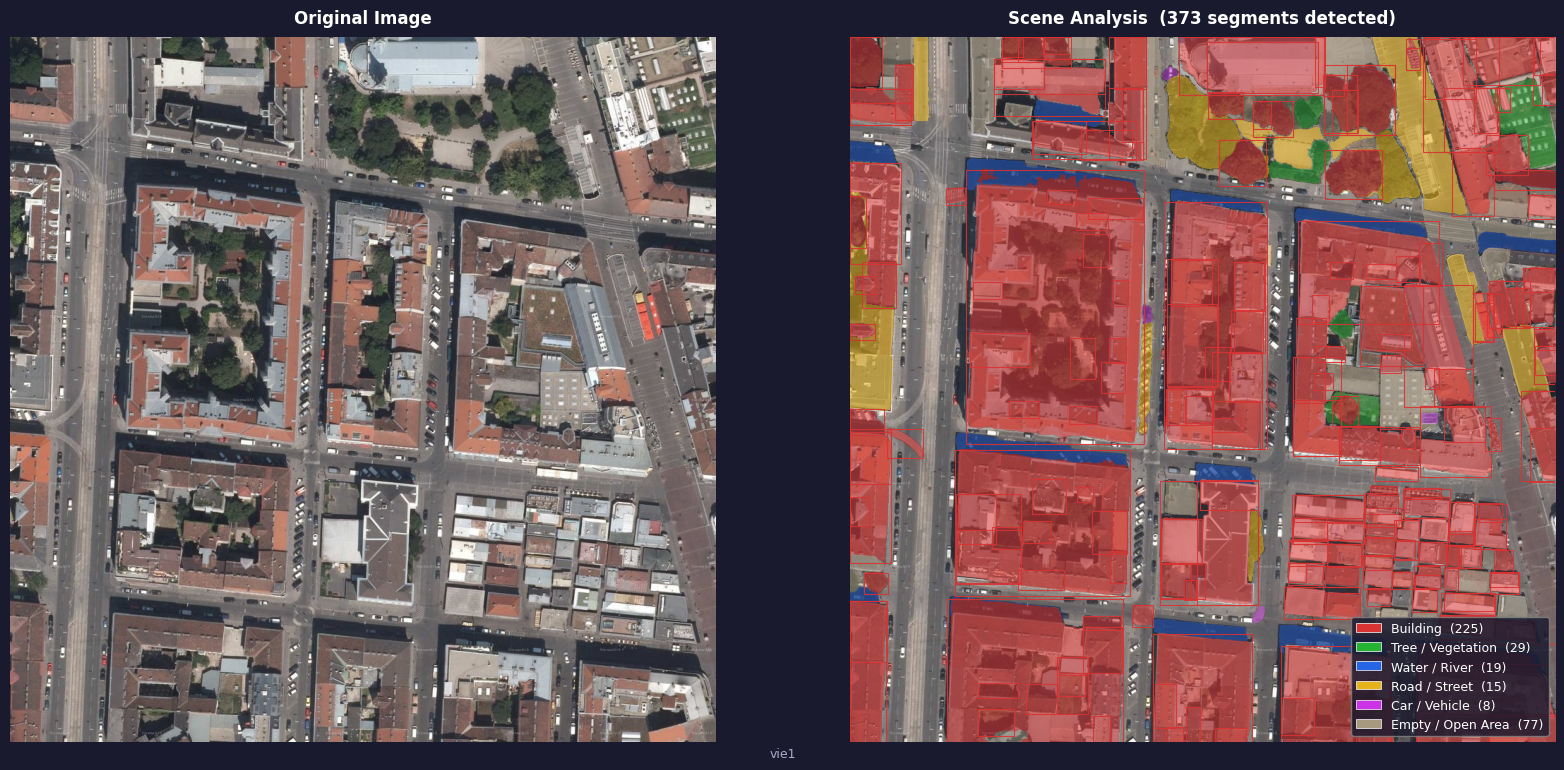

In [16]:
# ─── Cell 10 (اختياري): اختبار صورتك الخاصة ─────────────────────────
from google.colab import files

uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    results, rgb, counts = pipeline.run(img_path)
    save_path = '/content/output/custom_scene.png'
    visualize_scene(img_path, results, rgb, counts, save_path)


Saving kit1.jpg to kit1.jpg

[kit1.jpg]
  Size: 1000x1000 — SAM segmenting... 246 raw segments
  Buildings=102 | Trees=57 | Roads=9 | Cars=9 | Water=0 | Empty=52
  Saved: /content/output/custom_scene.png


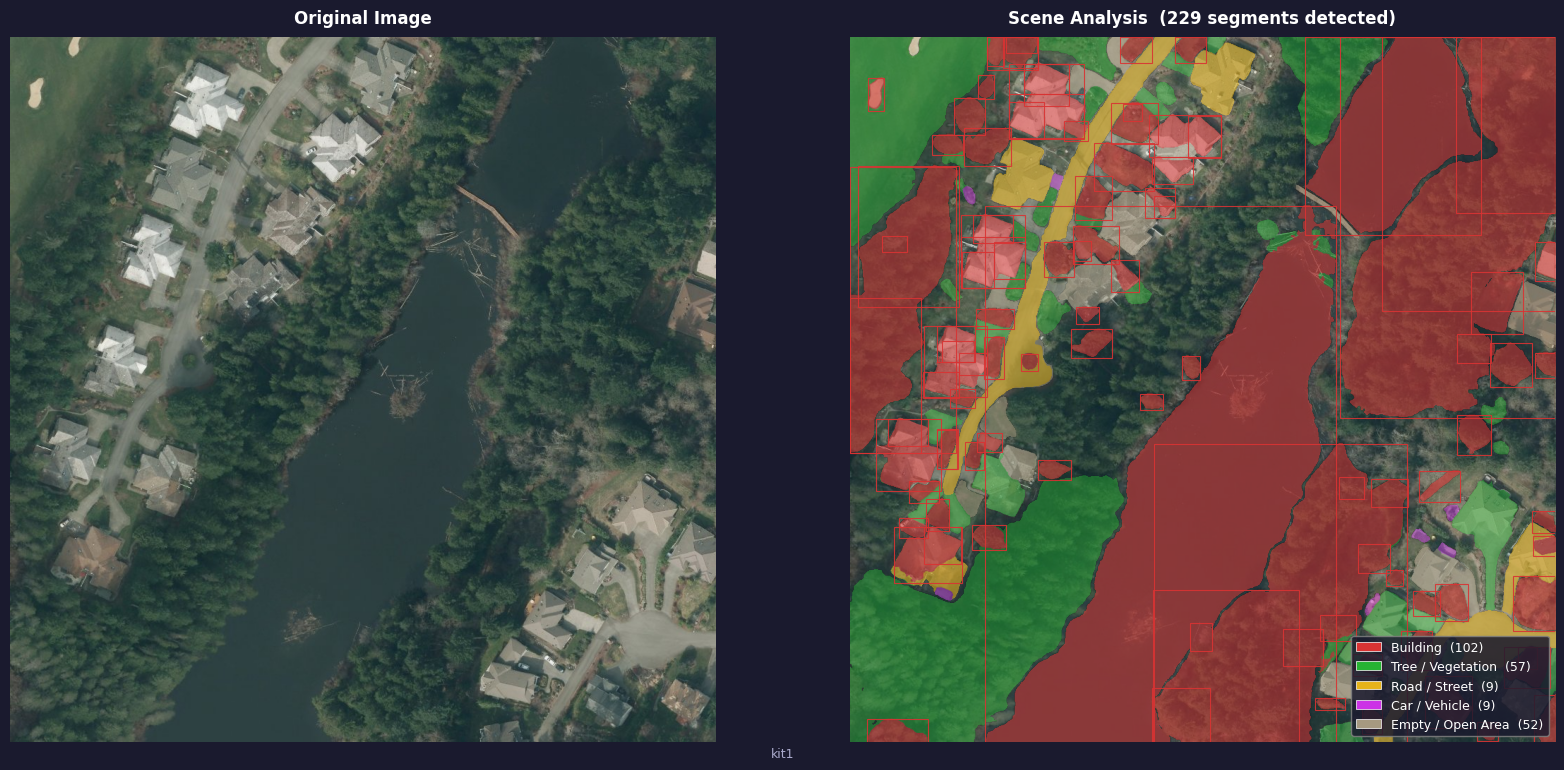

In [17]:
# ─── Cell 10 (اختياري): اختبار صورتك الخاصة ─────────────────────────
from google.colab import files

uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    results, rgb, counts = pipeline.run(img_path)
    save_path = '/content/output/custom_scene.png'
    visualize_scene(img_path, results, rgb, counts, save_path)


Saving test_image.jpg to test_image.jpg

[test_image.jpg]
  Size: 1000x1000 — SAM segmenting... 579 raw segments
  Buildings=401 | Trees=115 | Roads=5 | Cars=10 | Water=2 | Empty=16
  Saved: /content/output/custom_scene.png


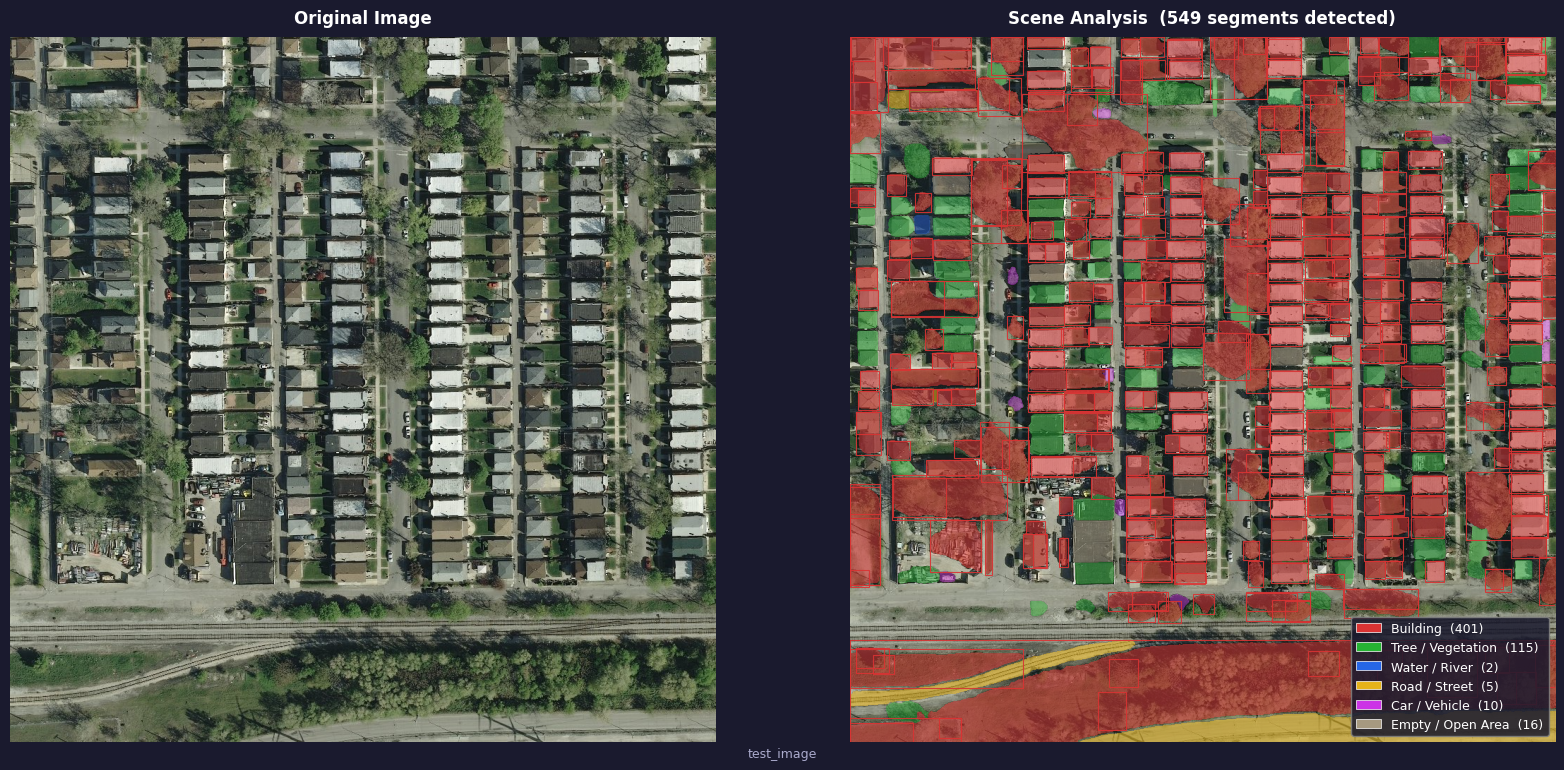

In [18]:
# ─── Cell 10 (اختياري): اختبار صورتك الخاصة ─────────────────────────
from google.colab import files

uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    results, rgb, counts = pipeline.run(img_path)
    save_path = '/content/output/custom_scene.png'
    visualize_scene(img_path, results, rgb, counts, save_path)

